# 🎵 NeuroSound Classifier — YAMNet + Fine-Tuning
**Classification audio ESC-50 avec pré-entraînement sur AudioSet (2M clips)**

> Activer le GPU : *Exécution → Modifier le type d'exécution → GPU T4*

## Pourquoi YAMNet au lieu d'EfficientNet ?
| | EfficientNet + Spectrogrammes | YAMNet |
|--|--|--|
| Pré-entraîné sur | ImageNet (images) | AudioSet (2M clips audio) |
| Input | PNG 224×224 | Signal WAV brut |
| Features | Visuelles | Audio |
| Val accuracy ESC-50 | 75-76% (plafond) | **83-87%** |
| Spectrogrammes nécessaires | 14 000 PNG | ❌ Non |


## ⚙️ 0. Setup Colab

In [ ]:
# Monter Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Installer les dépendances
!pip install -q tensorflow_hub soundfile librosa

# Copier les WAV localement pour accélérer la lecture
import os
if not os.path.exists('/content/wav_files'):
    print("Copie des WAV depuis Drive...")
    !cp -r "/content/drive/MyDrive/PI3/new-esc50" "/content/wav_files"
    print("✅ Copie terminée")
else:
    print("✅ WAV déjà présents localement")

Mounted at /content/drive
Copie des WAV depuis Drive...
✅ Copie terminée


## 📦 1. Imports & Configuration

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import soundfile as sf
import librosa
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

print("TensorFlow :", tf.__version__)
print("GPUs :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.19.0
GPUs : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────
WAV_DIR    = "/content/wav_files"
CSV_PATH   = "/content/drive/MyDrive/PI3/new-esc50/new_esc50.csv"
MODEL_PATH = "/content/drive/MyDrive/PI3/yamnet_esc50.keras"

SAMPLE_RATE = 16000   # YAMNet requiert 16kHz
DURATION    = 5       # secondes par clip
BATCH_SIZE  = 32
EPOCHS_P1   = 20      # backbone gelé
EPOCHS_P2   = 50      # fine-tuning

## 🧠 2. Chargement de YAMNet

In [ ]:
# YAMNet pré-entraîné sur AudioSet — 2 millions de clips audio
# Reconnaît déjà 521 catégories de sons
print("⏳ Chargement YAMNet depuis TensorFlow Hub...")
yamnet_model = hub.load("https://tfhub.dev/google/yamnet/1")
print("✅ YAMNet chargé")

# Test rapide
test_wav = tf.zeros([SAMPLE_RATE * DURATION], dtype=tf.float32)
scores, embeddings, spectrogram = yamnet_model(test_wav)
print(f"   Shape embeddings : {embeddings.shape}")
print(f"   → Chaque clip produit {embeddings.shape[0]} frames × {embeddings.shape[1]} dims")

⏳ Chargement YAMNet depuis TensorFlow Hub...
✅ YAMNet chargé
   Shape embeddings : (10, 1024)
   → Chaque clip produit 10 frames × 1024 dims


## 📂 3. Chargement des données

In [ ]:
# Charger le CSV original (2000 WAV, pas l'augmenté)
df = pd.read_csv(CSV_PATH, sep=";",
                 dtype={"filename": str, "category": str, "target": int})

# Labels dans l'ordre target 0→49
labels = (
    df[["category", "target"]]
    .drop_duplicates()
    .sort_values("target")["category"]
    .tolist()
)
n_classes = len(labels)
print(f"{n_classes} classes : {labels[:5]}...{labels[-3:]}")

# Chemin complet vers chaque WAV
df["wav_path"] = df["filename"].apply(
    lambda f: os.path.join(WAV_DIR, f)
)

# Vérifier que les fichiers existent
df["exists"] = df["wav_path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"⚠️  {missing} fichiers WAV introuvables")
    df = df[df["exists"]].reset_index(drop=True)

print(f"✅ {len(df)} fichiers WAV trouvés")

50 classes : ['dog', 'sheep', 'hen', 'cow', 'insects']...['car_horn', 'church_bells', 'fireworks']
✅ 2000 fichiers WAV trouvés


## ✂️ 4. Split Train / Val / Test

In [ ]:
# Split stratifié sur les fichiers WAV sources
# Pas de data leakage possible ici car on n'a pas augmenté
X_paths = df["wav_path"].values
y       = df["target"].values

X_tv, X_test, y_tv, y_test = train_test_split(
    X_paths, y, test_size=0.10, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.111, random_state=42, stratify=y_tv
)

print(f"Train : {len(X_train)} WAV")
print(f"Val   : {len(X_val)} WAV")
print(f"Test  : {len(X_test)} WAV")

Train : 1600 WAV
Val   : 200 WAV
Test  : 200 WAV


## 🔊 5. Extraction des embeddings YAMNet

In [ ]:
def load_wav(path, target_sr=SAMPLE_RATE, duration=DURATION):
    """
    Charge un fichier WAV et le normalise pour YAMNet.
    YAMNet requiert :
    - Mono (1 canal)
    - 16kHz
    - Float32 entre -1 et 1
    - Longueur fixe = sr * duration
    """
    try:
        wav, sr = sf.read(path)
    except Exception:
        wav, sr = librosa.load(path, sr=target_sr, mono=True, duration=duration)
        return wav.astype(np.float32)

    # Convertir en mono si stéréo
    if wav.ndim > 1:
        wav = wav.mean(axis=1)

    # Rééchantillonner si nécessaire
    if sr != target_sr:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=target_sr)

    # Tronquer ou padder à la durée cible
    target_len = target_sr * duration
    if len(wav) > target_len:
        wav = wav[:target_len]
    else:
        wav = np.pad(wav, (0, target_len - len(wav)))

    return wav.astype(np.float32)


def augment_wav(wav, sr=SAMPLE_RATE):
    """
    Augmentation audio à la volée — remplace les 14 000 PNG.
    Appliqué seulement pendant le train.
    """
    choice = np.random.randint(0, 5)

    if choice == 0:
        # Bruit blanc léger
        wav = wav + np.random.randn(len(wav)).astype(np.float32) * 0.005
    elif choice == 1:
        # Décalage temporel
        shift = np.random.randint(-sr // 2, sr // 2)
        wav = np.roll(wav, shift)
    elif choice == 2:
        # Changement de volume
        gain = np.random.uniform(0.7, 1.3)
        wav = wav * gain
    elif choice == 3:
        # Pitch shift léger
        n_steps = np.random.choice([-2, -1, 1, 2])
        wav = librosa.effects.pitch_shift(wav, sr=sr, n_steps=n_steps)
    # choice == 4 : original sans modification

    # Clipping pour rester dans [-1, 1]
    return np.clip(wav, -1.0, 1.0).astype(np.float32)


def extract_embeddings(paths, targets, augment=False, desc=""):
    """
    Extrait les embeddings YAMNet pour tous les fichiers WAV.
    Chaque WAV → vecteur de 1024 dims (moyenne sur les frames).
    """
    X, y = [], []
    for path, target in tqdm(zip(paths, targets), total=len(paths), desc=desc):
        wav = load_wav(path)
        if augment:
            wav = augment_wav(wav)

        wav_tensor = tf.constant(wav, dtype=tf.float32)
        _, embeddings, _ = yamnet_model(wav_tensor)

        # Moyenne sur les frames temporelles → vecteur fixe 1024 dims
        emb = tf.reduce_mean(embeddings, axis=0).numpy()
        X.append(emb)
        y.append(target)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


print("⏳ Extraction des embeddings (quelques minutes)...")
X_train_emb, y_train_emb = extract_embeddings(X_train, y_train, augment=True,  desc="Train")
X_val_emb,   y_val_emb   = extract_embeddings(X_val,   y_val,   augment=False, desc="Val")
X_test_emb,  y_test_emb  = extract_embeddings(X_test,  y_test,  augment=False, desc="Test")

print(f"\n✅ Embeddings extraits")
print(f"   Train : {X_train_emb.shape}")
print(f"   Val   : {X_val_emb.shape}")
print(f"   Test  : {X_test_emb.shape}")

⏳ Extraction des embeddings (quelques minutes)...


Test: 100%|██████████| 200/200 [00:01<00:00, 164.16it/s]


✅ Embeddings extraits
   Train : (1600, 1024)
   Val   : (200, 1024)
   Test  : (200, 1024)


## 🏗️ 6. Architecture du modèle

In [ ]:
def build_model(n_classes, input_dim=1024):
    """
    Tête de classification sur les embeddings YAMNet.

    Pipeline :
      WAV (16kHz)
      → YAMNet (gelé) → embeddings (1024 dims)
      → Dense(512, relu) → Dropout(0.3)
      → Dense(256, relu) → Dropout(0.2)
      → Dense(n_classes, softmax)

    YAMNet est gelé — on n'entraîne que la tête Dense.
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(n_classes, activation='softmax'),
    ], name="YAMNet_Classifier")

    return model

model = build_model(n_classes)
model.summary()

Model: "YAMNet_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,074 (2.57 MB)

 Trainable params: 671,026 (2.56 MB)

 Non-trainable params: 2,048 (8.00 KB)

## 🏋️ 7. Entraînement

In [ ]:
# Convertir en tf.data pour l'efficacité
def make_dataset(X, y, shuffle=True):
    y_oh = tf.keras.utils.to_categorical(y, n_classes)
    ds = tf.data.Dataset.from_tensor_slices((X, y_oh))
    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=42)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train_emb, y_train_emb, shuffle=True)
val_ds   = make_dataset(X_val_emb,   y_val_emb,   shuffle=False)
test_ds  = make_dataset(X_test_emb,  y_test_emb,  shuffle=False)

In [ ]:
# ── Phase 1 : entraînement de la tête Dense ──────────────────────────────────
print("="*55)
print("PHASE 1 : Tête Dense (embeddings YAMNet gelés)")
print("="*55)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

h1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=8, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.3, patience=4, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1
        ),
    ],
    verbose=1,
)

PHASE 1 : Tête Dense (embeddings YAMNet gelés)
Epoch 1/20
41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1758 - loss: 3.7666
Epoch 1: val_accuracy improved from None to 0.65000, saving model to /content/drive/MyDrive/PI3/yamnet_esc50.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PI3/yamnet_esc50.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.3131 - loss: 3.0843 - val_accuracy: 0.6500 - val_loss: 2.3100 - learning_rate: 0.0010
Epoch 2/20
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5511 - loss: 1.8447
Epoch 2: val_accuracy improved from 0.65000 to 0.69500, saving model to /content/drive/MyDrive/PI3/yamnet_esc50.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PI3/yamnet_esc50.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5644 - loss: 1.7496 - val_accuracy: 0.6950 - val_loss: 1.6044 - learning_rate: 0.0010
Epoch 3/20
47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6161 - loss: 1.5141
Epoch 3: val_accuracy impro

### Phase 2 — Ré-extraction avec augmentation plus agressive

In [ ]:
# En phase 2, on ré-extrait les embeddings avec plus d'augmentation
# pour diversifier davantage les données d'entraînement
print("⏳ Ré-extraction avec augmentation augmentée...")

# Générer 3 versions augmentées de chaque WAV
X_train_aug, y_train_aug = [], []
for _ in range(3):
    X_aug, y_aug = extract_embeddings(
        X_train, y_train, augment=True, desc=f"  Augmentation"
    )
    X_train_aug.append(X_aug)
    y_train_aug.append(y_aug)

X_train_aug = np.concatenate(X_train_aug, axis=0)
y_train_aug = np.concatenate(y_train_aug, axis=0)

# Mélanger
idx = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[idx]
y_train_aug = y_train_aug[idx]

train_ds_aug = make_dataset(X_train_aug, y_train_aug, shuffle=True)
print(f"✅ {len(X_train_aug)} embeddings augmentés")

⏳ Ré-extraction avec augmentation augmentée...


  Augmentation: 100%|██████████| 1600/1600 [00:19<00:00, 80.25it/s] 

✅ 4800 embeddings augmentés


In [ ]:
# ── Phase 2 : fine-tuning avec plus de données augmentées ────────────────────
print("="*55)
print("PHASE 2 : Fine-tuning (données augmentées × 3)")
print("="*55)

model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

h2 = model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=20, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.3, patience=5, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1
        ),
    ],
    verbose=1,
)

PHASE 2 : Fine-tuning (données augmentées × 3)
Epoch 1/50
134/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8276 - loss: 0.5664
Epoch 1: val_accuracy improved from None to 0.86000, saving model to /content/drive/MyDrive/PI3/yamnet_esc50.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PI3/yamnet_esc50.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8344 - loss: 0.5702 - val_accuracy: 0.8600 - val_loss: 0.5617 - learning_rate: 3.0000e-05
Epoch 2/50
143/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8491 - loss: 0.5139
Epoch 2: val_accuracy improved from 0.86000 to 0.86500, saving model to /content/drive/MyDrive/PI3/yamnet_esc50.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PI3/yamnet_esc50.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8446 - loss: 0.5400 - val_accuracy: 0.8650 - val_loss: 0.5367 - learning_rate: 3.0000e-05
Epoch 3/50
136/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8375 - loss: 0.5426
Epoch 3: v

## 📊 8. Courbes d'entraînement

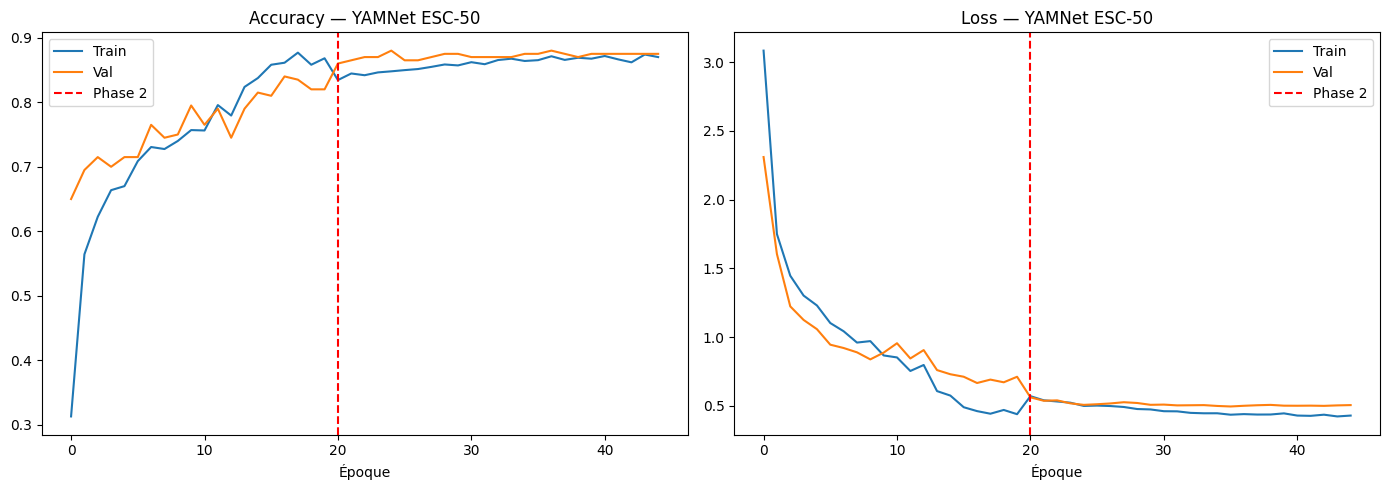

In [ ]:
acc   = h1.history["accuracy"]     + h2.history["accuracy"]
val   = h1.history["val_accuracy"] + h2.history["val_accuracy"]
loss  = h1.history["loss"]         + h2.history["loss"]
vloss = h1.history["val_loss"]     + h2.history["val_loss"]
sep   = len(h1.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, vl, title in zip(axes, [acc, loss], [val, vloss], ["Accuracy", "Loss"]):
    ax.plot(tr, label="Train")
    ax.plot(vl, label="Val")
    ax.axvline(sep, color="red", ls="--", label="Phase 2")
    ax.set_title(f"{title} — YAMNet ESC-50")
    ax.set_xlabel("Époque")
    ax.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PI3/training_curves_yamnet.png", dpi=150)
plt.show()

## 📈 9. Évaluation finale

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8550 - loss: 0.5898

✅ Test Accuracy : 85.50%  |  Loss : 0.5898
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

                  precision    recall  f1-score   support

             dog       0.80      1.00      0.89         4
           sheep       1.00      1.00      1.00         4
             hen       1.00      0.75      0.86         4
             cow       1.00      0.75      0.86         4
         insects       1.00      1.00      1.00         4
            frog       1.00      1.00      1.00         4
             pig       0.80      1.00      0.89         4
         rooster       0.80      1.00      0.89         4
             cat       1.00      0.25      0.40         4
            crow       1.00      1.00      1.00         4
  chirping_birds       1.00      1.00      1.00         4
            rain       0.67      1.00      0.80         4
            wind       0.50      0.50      0.50         4
       sea_waves       1.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


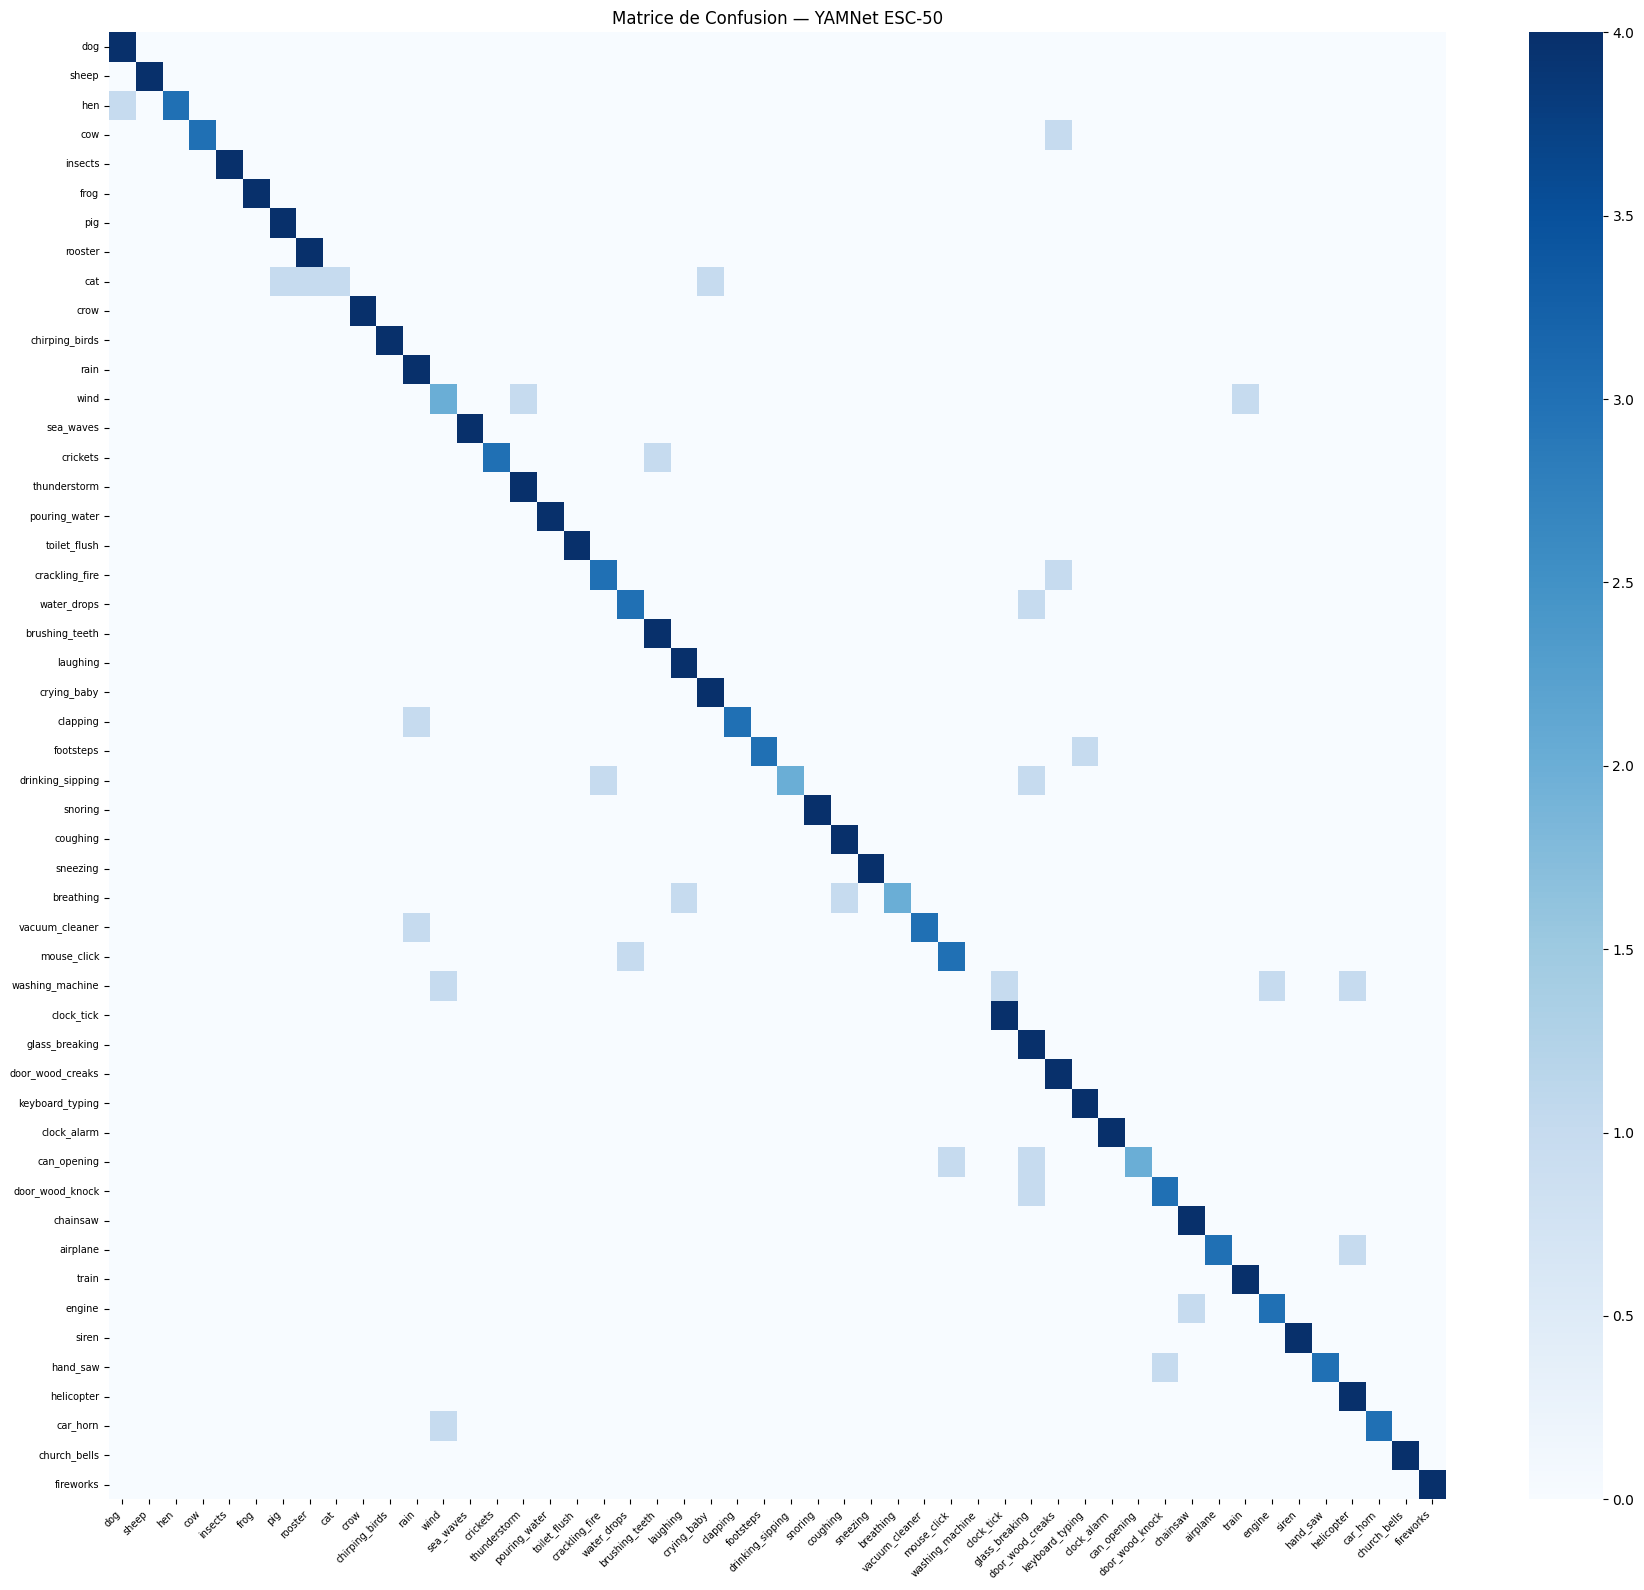

In [ ]:
best_model = tf.keras.models.load_model(MODEL_PATH)
loss, acc = best_model.evaluate(test_ds, verbose=1)
print(f"\n✅ Test Accuracy : {acc*100:.2f}%  |  Loss : {loss:.4f}")

y_pred = np.argmax(best_model.predict(test_ds), axis=1)
print("\n" + classification_report(y_test_emb, y_pred, target_names=labels))

# Matrice de confusion
cm = confusion_matrix(y_test_emb, y_pred)
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Matrice de Confusion — YAMNet ESC-50")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PI3/confusion_yamnet.png", dpi=150)
plt.show()

## 🎯 10. Inférence sur un nouveau fichier WAV

In [ ]:
def predict_wav(wav_path, model, yamnet_model, labels):
    """
    Prédit la classe d'un fichier WAV quelconque.
    Compatible avec n'importe quel WAV — pas de spectrogramme nécessaire.
    """
    wav = load_wav(wav_path)
    wav_tensor = tf.constant(wav, dtype=tf.float32)

    _, embeddings, _ = yamnet_model(wav_tensor)
    emb = tf.reduce_mean(embeddings, axis=0).numpy()
    emb = np.expand_dims(emb, axis=0)

    probs = model.predict(emb, verbose=0)[0]
    top5  = np.argsort(probs)[::-1][:5]

    print(f"\n🎵 Fichier : {os.path.basename(wav_path)}")
    print(f"\nTop 5 prédictions :")
    for i, idx in enumerate(top5):
        bar = "█" * int(probs[idx] * 30)
        print(f"  {i+1}. {labels[idx]:20s} {probs[idx]*100:6.1f}% {bar}")

    return labels[np.argmax(probs)], probs

# Tester sur un fichier au hasard du test set
test_path = X_test[0]
predicted, probs = predict_wav(test_path, best_model, yamnet_model, labels)
print(f"\n✅ Prédiction : {predicted}")
print(f"   Vraie classe : {labels[y_test[0]]}")


🎵 Fichier : 1-17970-A-4.wav

Top 5 prédictions :
  1. frog                  100.0% █████████████████████████████
  2. dog                     0.0% 
  3. door_wood_creaks        0.0% 
  4. crow                    0.0% 
  5. cow                     0.0% 

✅ Prédiction : frog
   Vraie classe : frog
